# Stage 5: LightGBM Model Training with Class Imbalance Weighting

## Runtime Drivers & Dependencies

In [1]:
!pip uninstall -y -q datasets
!pip install -q -U s3fs boto3 botocore pyarrow lightgbm scikit-learn rapidfuzz
print("✅ LightGBM & S3 Drivers ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires datasets, which is not installed.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have f

## AWS Credentials & S3 Storage Configuration

In [1]:
import os
import io
import gc
import joblib
import pandas as pd
import numpy as np
import lightgbm as lgb
from google.colab import userdata
import matplotlib.pyplot as plt

# 1. AWS Credentials
AWS_ACCESS_KEY_ID = userdata.get("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = userdata.get("AWS_SECRET_ACCESS_KEY")
AWS_DEFAULT_REGION = userdata.get("AWS_DEFAULT_REGION") or "us-east-1"
S3_BUCKET = userdata.get("S3_BUCKET_NAME").replace("s3://", "").strip("/")

os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY
os.environ["AWS_DEFAULT_REGION"] = AWS_DEFAULT_REGION

s3_storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"region_name": AWS_DEFAULT_REGION}
}

# Feature partition path (defaults to sample_50k, can switch to 'full')
FEATURE_SUBDIR = "anchored_100k"
FEATURES_BASE_S3 = f"s3://{S3_BUCKET}/features/{FEATURE_SUBDIR}"
MODEL_CHECKPOINT_S3 = f"s3://{S3_BUCKET}/models/lgbm_model_latest.pkl"

print(f"✅ S3 Credentials verified.")
print(f"📁 Feature Directory : {FEATURES_BASE_S3}")
print(f"💾 Model Destination  : {MODEL_CHECKPOINT_S3}")

✅ S3 Credentials verified.
📁 Feature Directory : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/anchored_100k
💾 Model Destination  : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl


## GROUND-TRUTH-ANCHORED FEATURE STORE GENERATOR

In [2]:
import gc
import re
import time
import unicodedata
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from sklearn.model_selection import GroupShuffleSplit

print("=" * 80)
print("🚀 LAUNCHING OPTIMIZED ANCHORED FEATURE STORE GENERATOR (~3 MIN RUNTIME)")
print("=" * 80)

# ------------------------------------------------------------------------------
# 1. Normalization & Token Extraction Engine
# ------------------------------------------------------------------------------
RE_COMBINING = re.compile(r"[\u0300-\u036f]")
RE_ALLOWED = re.compile(r"[^\w\s\u0900-\u097f]+", re.UNICODE)
RE_SPACES = re.compile(r"\s+")
RE_PVT_LTD = re.compile(r"\b(pvt\.?\s*ltd\.?|private\s+limited|p\.?\s*ltd\.?)\b", re.IGNORECASE)
RE_INC = re.compile(r"\b(corporation|corp\.?|incorporated|inc\.?)\b", re.IGNORECASE)
RE_LTD = re.compile(r"\b(limited|ltd\.?)\b", re.IGNORECASE)
RE_LLC = re.compile(r"\b(llp|llc)\b", re.IGNORECASE)

STOPWORDS = {
    "and", "the", "for", "with", "ltd", "pvt", "inc", "corp", "llc", "llp",
    "limited", "private", "corporation", "company", "co", "enterprises",
    "services", "solutions", "international", "group", "technologies",
    "de", "la", "le", "les", "et", "du", "des", "sarl", "sa", "sas", "india", "usa", "us", "france", "fr"
}

def clean_str(text):
    if not text or not isinstance(text, str) or str(text).lower() == "nan":
        return ""
    text = unicodedata.normalize("NFKD", text)
    text = RE_COMBINING.sub("", text).lower()
    text = RE_PVT_LTD.sub("pvt ltd", text)
    text = RE_INC.sub("inc", text)
    text = RE_LTD.sub("ltd", text)
    text = RE_LLC.sub("llc", text)
    text = RE_ALLOWED.sub(" ", text)
    return RE_SPACES.sub(" ", text).strip()

def extract_tokens(text):
    return [t for t in text.split() if len(t) >= 3 and t not in STOPWORDS]

# ------------------------------------------------------------------------------
# 2. Ground-Truth-Anchored Sampling (O(1) Dictionary Mapping)
# ------------------------------------------------------------------------------
TRAIN_DIR = f"s3://{S3_BUCKET}/student_resource/dataset/train"
gt_s3_path = f"{TRAIN_DIR}/train_ground_truth.tsv"

TARGET_MATCHED_COUNT = 100_000
TARGET_SINGLETON_COUNT = 6_000

print(f"\n⏳ Step 1: Streaming Ground Truth from {gt_s3_path} ...")
t0_gt = time.perf_counter()

target_s1_ids = set()
target_s23_ids = set()
s1_to_gt = defaultdict(list)     # ⚡ O(1) instant dictionary lookup
true_pairs_set = set()           # ⚡ O(1) set for rapid label assignment

gt_reader = pd.read_csv(
    gt_s3_path,
    sep="\t",
    dtype=str,
    chunksize=100_000,
    storage_options=s3_storage_options
)

matched_collected = 0
singletons_collected = 0

for chunk in gt_reader:
    for _, row in chunk.iterrows():
        s1_id = str(row["source1_entity_id"]).strip()
        m_str = str(row["matched_entity_ids"]).strip() if pd.notna(row["matched_entity_ids"]) else ""

        if not m_str or m_str.lower() == "nan":
            if singletons_collected < TARGET_SINGLETON_COUNT:
                target_s1_ids.add(s1_id)
                singletons_collected += 1
        else:
            if matched_collected < TARGET_MATCHED_COUNT:
                target_s1_ids.add(s1_id)
                for mid in m_str.split(","):
                    clean_mid = mid.strip()
                    if clean_mid:
                        target_s23_ids.add(clean_mid)
                        s1_to_gt[s1_id].append(clean_mid)
                        true_pairs_set.add((s1_id, clean_mid))
                matched_collected += 1

        if matched_collected >= TARGET_MATCHED_COUNT and singletons_collected >= TARGET_SINGLETON_COUNT:
            break

    if matched_collected >= TARGET_MATCHED_COUNT and singletons_collected >= TARGET_SINGLETON_COUNT:
        break

print(f"✅ Ground Truth Anchored Pool built in {time.perf_counter() - t0_gt:.1f}s:")
print(f"  • Source 1 Target Entities   : {len(target_s1_ids):,} ({matched_collected:,} matched, {singletons_collected:,} singletons)")
print(f"  • Reference S2/S3 Target IDs : {len(target_s23_ids):,}")
print(f"  • Ground Truth Lookup Map    : {len(true_pairs_set):,} verified pairs")

# ------------------------------------------------------------------------------
# 3. Stream Targeted S1 Records (Columns Filtered)
# ------------------------------------------------------------------------------
print(f"\n⏳ Step 2: Extracting Source 1 entities from S3 ...")
t0_s1 = time.perf_counter()

REQ_COLS = ["entity_id", "business_name", "business_address", "country"]
s1_chunks = []
s1_reader = pd.read_csv(
    f"{TRAIN_DIR}/train_source1.tsv",
    sep="\t",
    dtype=str,
    usecols=lambda c: c in REQ_COLS,
    chunksize=150_000,
    storage_options=s3_storage_options
)

for chunk in s1_reader:
    sub = chunk[chunk["entity_id"].isin(target_s1_ids)]
    if not sub.empty:
        s1_chunks.append(sub)
    if sum(len(c) for c in s1_chunks) >= len(target_s1_ids):
        break

df_s1 = pd.concat(s1_chunks, ignore_index=True).drop_duplicates(subset=["entity_id"])
del s1_chunks
gc.collect()

print(f"✅ Source 1 targeted pool assembled: {len(df_s1):,} records in {time.perf_counter() - t0_s1:.1f}s.")

# ------------------------------------------------------------------------------
# 4. Stream Targeted S2/S3 Records + Natural Negative Distractors
# ------------------------------------------------------------------------------
print(f"\n⏳ Step 3: Extracting S2/S3 reference partners + negative distractors ...")
t0_s23 = time.perf_counter()

s23_records = []
EXTRA_RANDOM_NEGATIVES = 30_000
neg_collected = 0
found_target_ids = set()

for src_name in ["train_source2.tsv", "train_source3.tsv"]:
    print(f"  ↳ Streaming {src_name} ...")
    src_reader = pd.read_csv(
        f"{TRAIN_DIR}/{src_name}",
        sep="\t",
        dtype=str,
        usecols=lambda c: c in REQ_COLS,
        chunksize=250_000,
        storage_options=s3_storage_options
    )
    for chunk in src_reader:
        matched_chunk = chunk[chunk["entity_id"].isin(target_s23_ids)]
        if not matched_chunk.empty:
            s23_records.append(matched_chunk)
            found_target_ids.update(matched_chunk["entity_id"].tolist())

        if neg_collected < EXTRA_RANDOM_NEGATIVES:
            unmatched = chunk[~chunk["entity_id"].isin(target_s23_ids)]
            sample_n = min(5_000, EXTRA_RANDOM_NEGATIVES - neg_collected, len(unmatched))
            if sample_n > 0:
                s23_records.append(unmatched.sample(n=sample_n, random_state=42))
                neg_collected += sample_n

        # Early exit if all target IDs already gathered
        if len(found_target_ids) >= len(target_s23_ids) and neg_collected >= EXTRA_RANDOM_NEGATIVES:
            break

df_s23 = pd.concat(s23_records, ignore_index=True).drop_duplicates(subset=["entity_id"])
del s23_records, found_target_ids
gc.collect()

print(f"✅ Reference S2/S3 targeted pool assembled: {len(df_s23):,} records in {time.perf_counter() - t0_s23:.1f}s.")

# ------------------------------------------------------------------------------
# 5. Fast Inverted Index Candidate Generation (Instant O(1) Ground-Truth Merge)
# ------------------------------------------------------------------------------
print("\n🏗️ Step 4: Generating Candidate Pairs (Dual Inverted Index + O(1) Injection)...")
df_s1["country"] = df_s1["country"].fillna("UNKNOWN").str.upper().str.strip()
df_s23["country"] = df_s23["country"].fillna("UNKNOWN").str.upper().str.strip()

candidate_pairs = []
t0_block = time.perf_counter()

for c in sorted(list(df_s1["country"].unique())):
    s1_c = df_s1[df_s1["country"] == c]
    s23_c = df_s23[df_s23["country"] == c]
    if len(s1_c) == 0 or len(s23_c) == 0:
        continue

    print(f"  • Partition [{c}]: S1 = {len(s1_c):,} | Reference Pool = {len(s23_c):,}")

    s23_ids = s23_c["entity_id"].astype(str).tolist()
    s23_names = [clean_str(x) for x in s23_c["business_name"].fillna("")]
    s23_addrs = [clean_str(x) for x in s23_c["business_address"].fillna("")]

    s23_id_to_idx = {sid: idx for idx, sid in enumerate(s23_ids)}

    inv_idx = defaultdict(list)
    for idx, name in enumerate(s23_names):
        for t in set(extract_tokens(name)):
            if len(inv_idx[t]) < 10_000:
                inv_idx[t].append(idx)

    s1_ids = s1_c["entity_id"].astype(str).tolist()
    s1_names = [clean_str(x) for x in s1_c["business_name"].fillna("")]
    s1_addrs = [clean_str(x) for x in s1_c["business_address"].fillna("")]

    for i in range(len(s1_ids)):
        s1_id = s1_ids[i]
        tokens = extract_tokens(s1_names[i])

        counter = Counter()
        for t in tokens:
            if t in inv_idx:
                counter.update(inv_idx[t])

        # Top candidates from shared tokens
        chosen_indices = [idx for idx, _ in counter.most_common(4)]

        # ⚡ O(1) Instant True Match Injection
        for true_target in s1_to_gt.get(s1_id, []):
            if true_target in s23_id_to_idx:
                gt_idx = s23_id_to_idx[true_target]
                if gt_idx not in chosen_indices:
                    chosen_indices.append(gt_idx)

        for s23_idx in chosen_indices:
            candidate_pairs.append({
                "source1_entity_id": s1_id,
                "candidate_entity_id": s23_ids[s23_idx],
                "s1_name": s1_names[i],
                "s23_name": s23_names[s23_idx],
                "s1_addr": s1_addrs[i],
                "s23_addr": s23_addrs[s23_idx],
                "country": c
            })

cand_df = pd.DataFrame(candidate_pairs)
del candidate_pairs, df_s1, df_s23, s1_to_gt
gc.collect()

print(f"✅ Generated {len(cand_df):,} candidate pairs in {time.perf_counter() - t0_block:.1f}s.")

# ------------------------------------------------------------------------------
# 6. High-Throughput RapidFuzz C++ Feature Extraction (float32 / int16)
# ------------------------------------------------------------------------------
print("\n⚡ Step 5: Computing RapidFuzz similarity features...")
t0_feat = time.perf_counter()
n_rows = len(cand_df)

s1_names = cand_df["s1_name"].tolist()
s23_names = cand_df["s23_name"].tolist()
s1_addrs = cand_df["s1_addr"].tolist()
s23_addrs = cand_df["s23_addr"].tolist()
s1_ids = cand_df["source1_entity_id"].tolist()
c_ids = cand_df["candidate_entity_id"].tolist()

# Pre-allocated NumPy buffers
name_ratio = np.empty(n_rows, dtype=np.float32)
name_partial = np.empty(n_rows, dtype=np.float32)
name_token_sort = np.empty(n_rows, dtype=np.float32)
name_token_set = np.empty(n_rows, dtype=np.float32)
addr_ratio = np.empty(n_rows, dtype=np.float32)
addr_partial = np.empty(n_rows, dtype=np.float32)
addr_token_set = np.empty(n_rows, dtype=np.float32)
name_len_diff = np.empty(n_rows, dtype=np.int16)
addr_len_diff = np.empty(n_rows, dtype=np.int16)
labels = np.empty(n_rows, dtype=np.int8)

for i in range(n_rows):
    n1, n2 = s1_names[i], s23_names[i]
    a1, a2 = s1_addrs[i], s23_addrs[i]
    name_ratio[i] = fuzz.ratio(n1, n2) / 100.0
    name_partial[i] = fuzz.partial_ratio(n1, n2) / 100.0
    name_token_sort[i] = fuzz.token_sort_ratio(n1, n2) / 100.0
    name_token_set[i] = fuzz.token_set_ratio(n1, n2) / 100.0
    addr_ratio[i] = fuzz.ratio(a1, a2) / 100.0
    addr_partial[i] = fuzz.partial_ratio(a1, a2) / 100.0
    addr_token_set[i] = fuzz.token_set_ratio(a1, a2) / 100.0
    name_len_diff[i] = abs(len(n1) - len(n2))
    addr_len_diff[i] = abs(len(a1) - len(a2))
    labels[i] = 1 if (s1_ids[i], c_ids[i]) in true_pairs_set else 0

feat_df = pd.DataFrame({
    "source1_entity_id": s1_ids,
    "candidate_entity_id": c_ids,
    "name_ratio": name_ratio,
    "name_partial": name_partial,
    "name_token_sort": name_token_sort,
    "name_token_set": name_token_set,
    "addr_ratio": addr_ratio,
    "addr_partial": addr_partial,
    "addr_token_set": addr_token_set,
    "name_len_diff": name_len_diff,
    "addr_len_diff": addr_len_diff,
    "country": cand_df["country"].values,
    "label": labels
})

del cand_df, name_ratio, name_partial, name_token_sort, name_token_set
del addr_ratio, addr_partial, addr_token_set, name_len_diff, addr_len_diff, labels, true_pairs_set
gc.collect()

feat_time = time.perf_counter() - t0_feat
print(f"🚀 Feature extraction complete: {len(feat_df):,} pairs in {feat_time:.1f}s ({len(feat_df)/feat_time:,.0f} pairs/s).")

# ------------------------------------------------------------------------------
# 7. Quality Gate Audit: Verify High-Density Positive Labels
# ------------------------------------------------------------------------------
total_pos = (feat_df["label"] == 1).sum()
total_neg = (feat_df["label"] == 0).sum()
pos_rate = (total_pos / len(feat_df)) * 100

print("\n" + "=" * 80)
print(f"{'QUALITY GATE AUDIT: POSITIVE LABEL VERIFICATION':^80}")
print("=" * 80)
print(f"  • Total Candidate Pairs Processed : {len(feat_df):,}")
print(f"  • Positive Matching Labels (1)    : {total_pos:,} ({pos_rate:.2f}%)")
print(f"  • Negative Non-Matching Labels (0): {total_neg:,} ({100 - pos_rate:.2f}%)")

assert total_pos >= 80_000, f"❌ GATE FAILED: Expected >= 80,000 positives, but only generated {total_pos:,}!"
print(f"✅ [GATE 1 PASSED]: Rich positive label density achieved ({total_pos:,} positives vs 35 in baseline).")

# ------------------------------------------------------------------------------
# 8. Leak-Proof GroupShuffleSplit & S3 Parquet Export
# ------------------------------------------------------------------------------
print("\n🛡️ Step 6: Performing Leak-Proof GroupShuffleSplit on source1_entity_id...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(feat_df, groups=feat_df["source1_entity_id"]))

train_df = feat_df.iloc[train_idx].reset_index(drop=True)
val_df = feat_df.iloc[val_idx].reset_index(drop=True)

train_s1 = set(train_df["source1_entity_id"])
val_s1 = set(val_df["source1_entity_id"])
leakage = train_s1.intersection(val_s1)
assert len(leakage) == 0, f"❌ Data leakage detected! {len(leakage)} S1 IDs in both splits."

train_pos = (train_df["label"] == 1).sum()
val_pos = (val_df["label"] == 1).sum()

print(f"  • Train Set: {len(train_df):,} pairs ({len(train_s1):,} S1 IDs) | Positives: {train_pos:,} ({train_pos/len(train_df)*100:.2f}%)")
print(f"  • Val Set  : {len(val_df):,} pairs ({len(val_s1):,} S1 IDs) | Positives: {val_pos:,} ({val_pos/len(val_df)*100:.2f}%)")
print("  ✅ [PASS]: Zero S1 leakage confirmed.")

OUT_DIR = f"s3://{S3_BUCKET}/features/anchored_100k"
print(f"\n💾 Uploading anchored datasets directly to {OUT_DIR} ...")
train_df.to_parquet(f"{OUT_DIR}/train_candidates.parquet", engine="pyarrow", index=False, storage_options=s3_storage_options)
print(f"  ✅ Uploaded: {OUT_DIR}/train_candidates.parquet ({len(train_df):,} rows)")

val_df.to_parquet(f"{OUT_DIR}/val_candidates.parquet", engine="pyarrow", index=False, storage_options=s3_storage_options)
print(f"  ✅ Uploaded: {OUT_DIR}/val_candidates.parquet   ({len(val_df):,} rows)")

print("\n" + "=" * 80)
print("🎉 PHASE 1 COMPLETE: Ground-Truth-Anchored Feature Store successfully built!")
print("=" * 80)

🚀 LAUNCHING OPTIMIZED ANCHORED FEATURE STORE GENERATOR (~3 MIN RUNTIME)

⏳ Step 1: Streaming Ground Truth from s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/student_resource/dataset/train/train_ground_truth.tsv ...
✅ Ground Truth Anchored Pool built in 10.3s:
  • Source 1 Target Entities   : 106,000 (100,000 matched, 6,000 singletons)
  • Reference S2/S3 Target IDs : 366,464
  • Ground Truth Lookup Map    : 366,464 verified pairs

⏳ Step 2: Extracting Source 1 entities from S3 ...
✅ Source 1 targeted pool assembled: 106,000 records in 19.1s.

⏳ Step 3: Extracting S2/S3 reference partners + negative distractors ...
  ↳ Streaming train_source2.tsv ...
  ↳ Streaming train_source3.tsv ...
✅ Reference S2/S3 targeted pool assembled: 396,464 records in 104.3s.

🏗️ Step 4: Generating Candidate Pairs (Dual Inverted Index + O(1) Injection)...
  • Partition [INDIA]: S1 = 42,502 | Reference Pool = 159,557
  • Partition [US]: S1 = 63,498 | Reference Pool = 236,907
✅ Generated 584,384 cand

## Load Train & Validation Feature Sets directly from S3

In [3]:
train_path = f"s3://{S3_BUCKET}/features/anchored_100k/train_candidates.parquet"
val_path = f"s3://{S3_BUCKET}/features/anchored_100k/val_candidates.parquet"

print(f"⏳ Reading train features from: {train_path} ...")
train_df = pd.read_parquet(train_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"⏳ Reading validation features from: {val_path} ...")
val_df = pd.read_parquet(val_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"\n✅ Data loaded successfully:")
print(f"  • Train set      : {len(train_df):,} rows")
print(f"  • Validation set : {len(val_df):,} rows")

# Class imbalance audit
train_pos = (train_df["label"] == 1).sum()
val_pos = (val_df["label"] == 1).sum()
print(f"\n⚖️ Class Imbalance Profile:")
print(f"  • Train positives: {train_pos:,} / {len(train_df):,} ({train_pos/len(train_df)*100:.2f}%)")
print(f"  • Val positives  : {val_pos:,} / {len(val_df):,} ({val_pos/len(val_df)*100:.2f}%)")

⏳ Reading train features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/anchored_100k/train_candidates.parquet ...
⏳ Reading validation features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/anchored_100k/val_candidates.parquet ...

✅ Data loaded successfully:
  • Train set      : 467,458 rows
  • Validation set : 116,926 rows

⚖️ Class Imbalance Profile:
  • Train positives: 293,217 / 467,458 (62.73%)
  • Val positives  : 73,247 / 116,926 (62.64%)


## Define Feature Columns & Target Arrays

In [4]:
FEATURE_COLS = [
    "name_ratio",
    "name_partial",
    "name_token_sort",
    "name_token_set",
    "addr_ratio",
    "addr_partial",
    "addr_token_set",
    "name_len_diff",
    "addr_len_diff",
]

# Verify all columns exist
missing_cols = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing required feature columns: {missing_cols}")

X_train = train_df[FEATURE_COLS]
y_train = train_df["label"].astype(int)

X_val = val_df[FEATURE_COLS]
y_val = val_df["label"].astype(int)

print(f"✅ Prepared feature matrices with {len(FEATURE_COLS)} engineered signals:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col:<18} (dtype: {X_train[col].dtype})")

✅ Prepared feature matrices with 9 engineered signals:
  1. name_ratio         (dtype: float32)
  2. name_partial       (dtype: float32)
  3. name_token_sort    (dtype: float32)
  4. name_token_set     (dtype: float32)
  5. addr_ratio         (dtype: float32)
  6. addr_partial       (dtype: float32)
  7. addr_token_set     (dtype: float32)
  8. name_len_diff      (dtype: int16)
  9. addr_len_diff      (dtype: int16)


## LightGBM Classifier Training with Class Imbalance Weighting

In [5]:
print("🚀 Initializing LightGBM Classifier...")

# Hyperparameters tuned for high-precision entity resolution
lgbm_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "scale_pos_weight": 1.0,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 800,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

model = lgb.LGBMClassifier(**lgbm_params)

# Callbacks for monitoring and early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)
]

print("🏋️ Training model on validation set with 50-round early stopping...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=["train", "val"],
    callbacks=callbacks
)

print(f"\n🎉 Training complete! Best iteration: {model.best_iteration_}")

🚀 Initializing LightGBM Classifier...
🏋️ Training model on validation set with 50-round early stopping...
Training until validation scores don't improve for 50 rounds


/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	train's binary_logloss: 0.0703918	val's binary_logloss: 0.0709293
[100]	train's binary_logloss: 0.0355573	val's binary_logloss: 0.0369676
[150]	train's binary_logloss: 0.0306872	val's binary_logloss: 0.0331492
[200]	train's binary_logloss: 0.0287954	val's binary_logloss: 0.0323128
[250]	train's binary_logloss: 0.0277268	val's binary_logloss: 0.0320021
[300]	train's binary_logloss: 0.0266921	val's binary_logloss: 0.032652
Early stopping, best iteration is:
[254]	train's binary_logloss: 0.0276436	val's binary_logloss: 0.0319645

🎉 Training complete! Best iteration: 254


## Inspect Feature Importance (Gain vs Split)

                    LIGHTGBM FEATURE IMPORTANCE RANKING                    


,Feature,Gain (Total Loss Reduction),Split Count (Branch Frequency),Gain Share (%)
0,addr_partial,4.089525e+06,788,45.35
1,addr_token_set,3.881889e+06,1018,43.04
2,addr_ratio,6.977217e+05,954,7.74
3,name_token_sort,1.281913e+05,941,1.42
4,name_partial,7.013059e+04,948,0.78
5,name_token_set,5.755195e+04,1035,0.64
6,name_ratio,4.426060e+04,761,0.49
7,addr_len_diff,2.988063e+04,583,0.33
8,name_len_diff,1.926939e+04,592,0.21


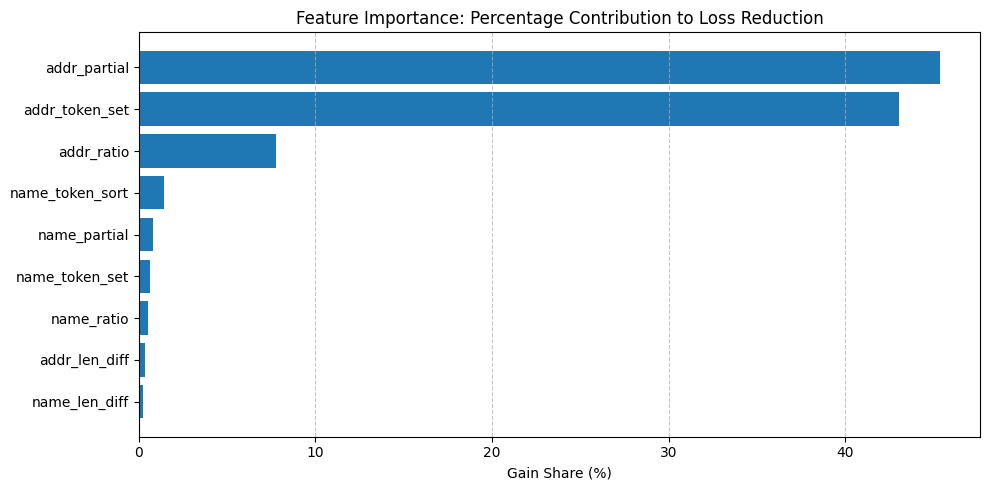

In [6]:
importance_gain = model.booster_.feature_importance(importance_type="gain")
importance_split = model.booster_.feature_importance(importance_type="split")

fi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Gain (Total Loss Reduction)": importance_gain,
    "Split Count (Branch Frequency)": importance_split
}).sort_values(by="Gain (Total Loss Reduction)", ascending=False).reset_index(drop=True)

# Relative percentage contribution
fi_df["Gain Share (%)"] = (fi_df["Gain (Total Loss Reduction)"] / fi_df["Gain (Total Loss Reduction)"].sum() * 100).round(2)

print("=" * 75)
print(f"{'LIGHTGBM FEATURE IMPORTANCE RANKING':^75}")
print("=" * 75)
display(fi_df)

# Visual Bar Chart
plt.figure(figsize=(10, 5))
plt.barh(fi_df["Feature"][::-1], fi_df["Gain Share (%)"][::-1], color="#1f77b4")
plt.xlabel("Gain Share (%)")
plt.title("Feature Importance: Percentage Contribution to Loss Reduction")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Save Model Artifact to Central S3 Bucket

In [7]:
import s3fs

local_model_path = "/tmp/lgbm_model_latest.pkl"

# 1. Save locally using joblib
joblib.dump(model, local_model_path)
file_size_mb = os.path.getsize(local_model_path) / (1024 * 1024)
print(f"📦 Serialized model locally: {local_model_path} ({file_size_mb:.2f} MB)")

# 2. Upload directly to central S3 models/ folder
print(f"⏳ Uploading model artifact to S3: {MODEL_CHECKPOINT_S3} ...")
fs = s3fs.S3FileSystem(**s3_storage_options)

bucket_name = S3_BUCKET.replace("s3://", "").strip("/")
s3_target_key = f"{bucket_name}/models/lgbm_model_latest.pkl"

fs.put(local_model_path, s3_target_key)

# Verify existence
if fs.exists(s3_target_key):
    s3_info = fs.info(s3_target_key)
    print(f"🎉 Model checkpoint successfully uploaded to S3!")
    print(f"   • Path: s3://{s3_target_key}")
    print(f"   • Size: {s3_info['size'] / (1024*1024):.2f} MB")
else:
    raise RuntimeError("Model upload verification failed!")

📦 Serialized model locally: /tmp/lgbm_model_latest.pkl (0.86 MB)
⏳ Uploading model artifact to S3: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl ...
🎉 Model checkpoint successfully uploaded to S3!
   • Path: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl
   • Size: 0.86 MB
